<a href="https://colab.research.google.com/github/244107020170-png/244107020170-mobile-course/blob/main/week5_22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Nasywa Qonita Ramadhani Han'
NIM = '244107020170'

N = int(NIM[-3:])

PARAM = {
    'bins': 2 ** ((N % 4) + 3),
    'clip': round(1.0 + (N % 5) * 0.5, 1),
    'tile': (N % 4) + 2,
    'L': 2 ** ((N % 3) + 1),
}

waktu = datetime.datetime.now(
    zoneinfo.ZoneInfo('Asia/Jakarta')
)

print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)

for k, v in PARAM.items():
    print('%-6s :' % k, v)

print(
    'WAKTU :',
    waktu.strftime('%Y-%m-%d %H:%M:%S %Z')
)

print(
    'SISTEM :',
    sys.version.split()[0],
    platform.platform()
)

kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')

print(
    'TOKEN :',
    hashlib.sha256(kunci.encode()).hexdigest()[:16]
)

NAMA : Nasywa Qonita Ramadhani Han
NIM : 244107020170 | N = 170
bins   : 32
clip   : 1.0
tile   : 4
L      : 8
WAKTU : 2026-10-01 08:20:17 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : 7124a5cbb41a4614


In [2]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import os

In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
CONTOH = '/content/drive/MyDrive/.work/PCdVK/Images'
BASE = '/content/drive/MyDrive/.work/PCdVK/Images/' + NIM

print("CONTOH :", CONTOH)
print("BASE   :", BASE)

print("\nCONTOH exists:", os.path.exists(CONTOH))
print("BASE exists  :", os.path.exists(BASE))

CONTOH : /content/drive/MyDrive/.work/PCdVK/Images
BASE   : /content/drive/MyDrive/.work/PCdVK/Images/244107020170

CONTOH exists: True
BASE exists  : True


In [6]:
print("=== FILE CONTOH ===")

for file in sorted(os.listdir(CONTOH)):
    print(file)

=== FILE CONTOH ===
.ipynb_checkpoints
244107020170
2D Geometry Images
KTM lama.jpg
Object Detection
anna.jpg
corak.bmp
couple.tiff
crayfish.jpg
crossword.jpg
facedet
female.tiff
galaxy.jpg
gradient.jpg
haarcascades
j.png
jungle.png
kitten01.jpg
ktp.jpg
leaves.jpg
lena.jpg
lena_gs_lc.jpg
lena_gs_lc2.jpg
night.jpeg
noises


In [7]:
print("=== FILE KTM ===")

if os.path.exists(BASE):
    for file in sorted(os.listdir(BASE)):
        print(file)
else:
    print("Folder KTM belum ditemukan.")

=== FILE KTM ===
KTM1a.jpeg
KTM1b.jpeg
KTM1c.jpeg
KTM1d.jpeg


In [9]:
def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)

    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h[img[y, x]] += 1

    return h

In [10]:
img_lena = cv.imread(CONTOH + '/lena.jpg', cv.IMREAD_GRAYSCALE)

assert img_lena is not None, "lena.jpg tidak ditemukan!"

h_manual = histogram_manual(img_lena)

h_numpy, _ = np.histogram(
    img_lena,
    bins=256,
    range=(0, 256)
)

h_cv = cv.calcHist(
    [img_lena],
    [0],
    None,
    [256],
    [0, 256]
).ravel()

diff_manual_numpy = np.max(
    np.abs(h_manual.astype(np.int64) - h_numpy.astype(np.int64))
)

diff_manual_cv = np.max(
    np.abs(h_manual.astype(np.int64) - h_cv.astype(np.int64))
)

diff_numpy_cv = np.max(
    np.abs(h_numpy.astype(np.int64) - h_cv.astype(np.int64))
)

print("Manual vs NumPy :", diff_manual_numpy)
print("Manual vs OpenCV:", diff_manual_cv)
print("NumPy vs OpenCV :", diff_numpy_cv)

Manual vs NumPy : 0
Manual vs OpenCV: 0
NumPy vs OpenCV : 0


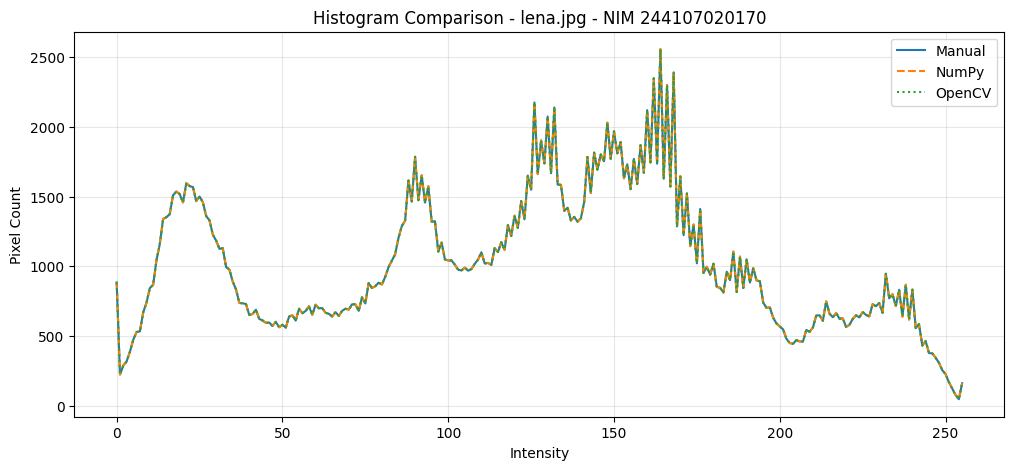

In [11]:
plt.figure(figsize=(12, 5))

plt.plot(h_manual, label='Manual')
plt.plot(h_numpy, '--', label='NumPy')
plt.plot(h_cv, ':', label='OpenCV')

plt.title(f'Histogram Comparison - lena.jpg - NIM {NIM}')
plt.xlabel('Intensity')
plt.ylabel('Pixel Count')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [13]:
img_ktm = cv.imread(BASE + '/KTM1b.jpeg', cv.IMREAD_GRAYSCALE)

assert img_ktm is not None, "KTM1b.jpeg tidak ditemukan!"

h_manual_ktm = histogram_manual(img_ktm)

h_numpy_ktm, _ = np.histogram(
    img_ktm,
    bins=256,
    range=(0, 256)
)

h_cv_ktm = cv.calcHist(
    [img_ktm],
    [0],
    None,
    [256],
    [0, 256]
).ravel()

diff_manual_numpy_ktm = np.max(
    np.abs(
        h_manual_ktm.astype(np.int64) -
        h_numpy_ktm.astype(np.int64)
    )
)

diff_manual_cv_ktm = np.max(
    np.abs(
        h_manual_ktm.astype(np.int64) -
        h_cv_ktm.astype(np.int64)
    )
)

diff_numpy_cv_ktm = np.max(
    np.abs(
        h_numpy_ktm.astype(np.int64) -
        h_cv_ktm.astype(np.int64)
    )
)

print("Manual vs NumPy :", diff_manual_numpy_ktm)
print("Manual vs OpenCV:", diff_manual_cv_ktm)
print("NumPy vs OpenCV :", diff_numpy_cv_ktm)

Manual vs NumPy : 0
Manual vs OpenCV: 0
NumPy vs OpenCV : 0


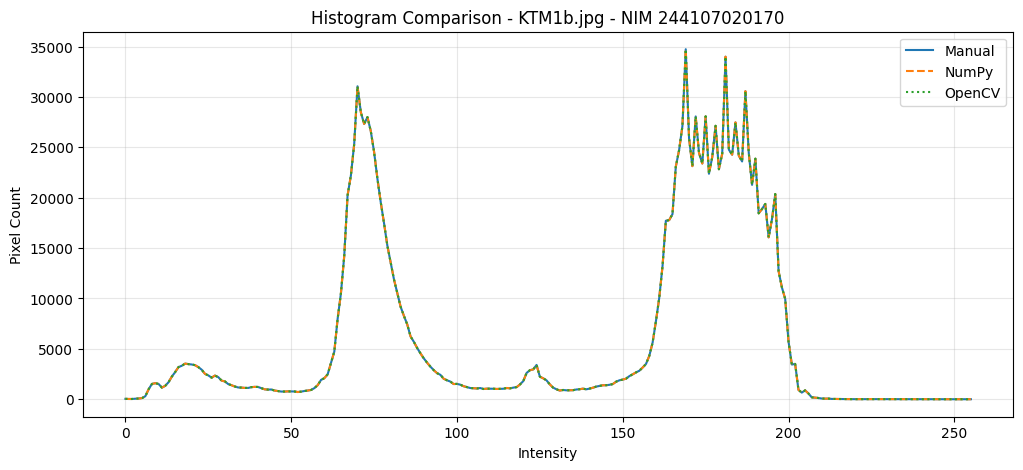

In [14]:
plt.figure(figsize=(12, 5))

plt.plot(h_manual_ktm, label='Manual')
plt.plot(h_numpy_ktm, '--', label='NumPy')
plt.plot(h_cv_ktm, ':', label='OpenCV')

plt.title(f'Histogram Comparison - KTM1b.jpg - NIM {NIM}')
plt.xlabel('Intensity')
plt.ylabel('Pixel Count')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

E-1 Question 1 — Answer

The histogram generated using the manual method, NumPy, and OpenCV is equivalent. The maximum difference between the three methods is 0 for both lena.jpg and KTM1b.jpeg. This confirms that the three histogram implementations produce the same pixel-intensity distribution.

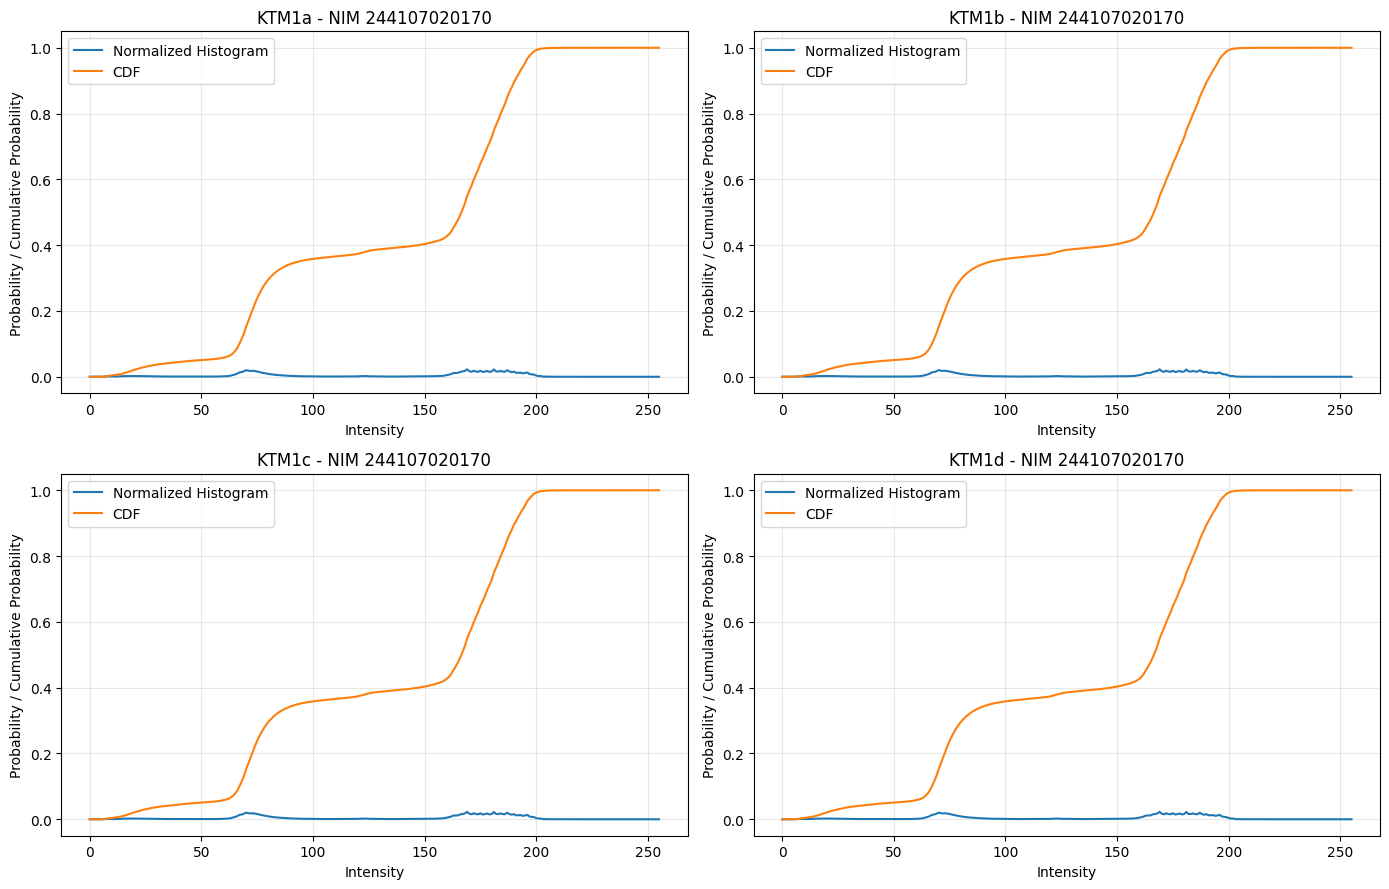

In [16]:
ktm_names = ['KTM1a', 'KTM1b', 'KTM1c', 'KTM1d']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, name in zip(axes.ravel(), ktm_names):

    img = cv.imread(BASE + f'/{name}.jpeg', cv.IMREAD_GRAYSCALE)

    assert img is not None, f'{name}.jpeg tidak ditemukan!'

    h = histogram_manual(img)
    p = h / img.size
    cdf = np.cumsum(p)

    ax.plot(p, label='Normalized Histogram')
    ax.plot(cdf, label='CDF')

    ax.set_title(f'{name} - NIM {NIM}')
    ax.set_xlabel('Intensity')
    ax.set_ylabel('Probability / Cumulative Probability')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The CDF of the darkest image is concentrated toward lower intensity values because most pixels are dark. In contrast, the brightest image has its intensity distribution shifted toward higher values, so its CDF increases mainly at brighter intensity levels. This difference is caused by the lighting conditions during image acquisition: darker illumination produces lower pixel intensities, while stronger illumination such as flash or sunlight produces higher intensities.

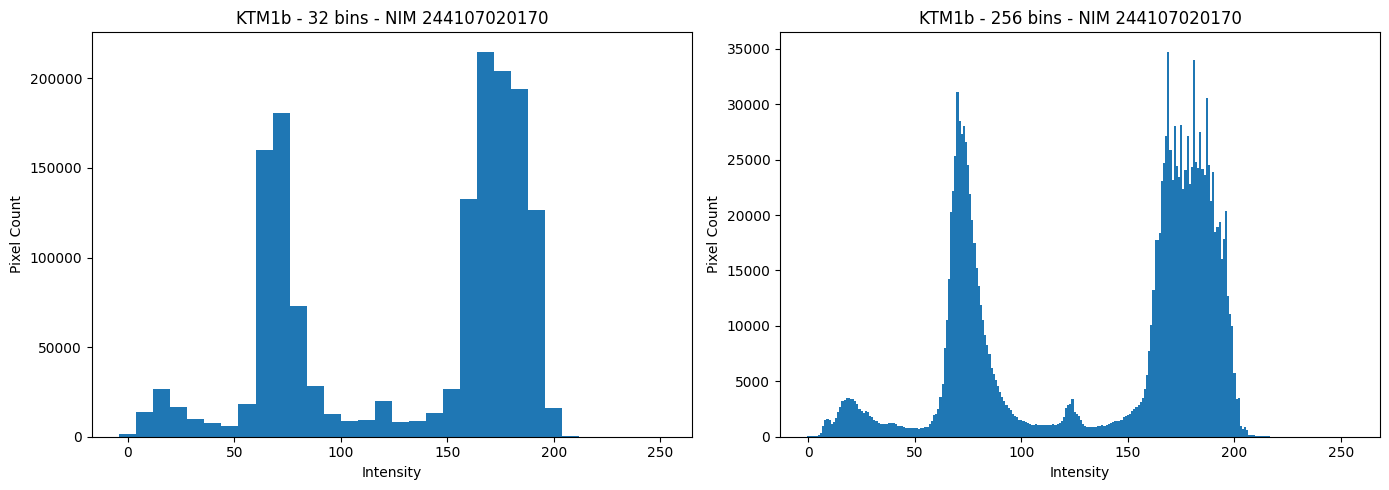

In [17]:
bins_param = PARAM['bins']

h_param, edges_param = np.histogram(
    img_ktm,
    bins=bins_param,
    range=(0, 256)
)

h_256, edges_256 = np.histogram(
    img_ktm,
    bins=256,
    range=(0, 256)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(
    edges_param[:-1],
    h_param,
    width=256 / bins_param
)
axes[0].set_title(
    f'KTM1b - {bins_param} bins - NIM {NIM}'
)
axes[0].set_xlabel('Intensity')
axes[0].set_ylabel('Pixel Count')

axes[1].bar(
    edges_256[:-1],
    h_256,
    width=1
)
axes[1].set_title(
    f'KTM1b - 256 bins - NIM {NIM}'
)
axes[1].set_xlabel('Intensity')
axes[1].set_ylabel('Pixel Count')

plt.tight_layout()
plt.show()

Using fewer bins groups several intensity values into the same interval. This makes the histogram simpler and easier to observe at a general level, but it loses fine-grained information about the exact distribution of pixel intensities. The 256-bin histogram provides more detailed information about individual intensity levels.

In [18]:
def manual_equalize(img):
    h = histogram_manual(img)
    cdf = np.cumsum(h)

    cdf_min = cdf[cdf > 0][0]
    total_pixels = img.size

    lut = np.round(
        (cdf - cdf_min) /
        (total_pixels - cdf_min) *
        255
    )

    lut = np.clip(lut, 0, 255).astype(np.uint8)

    return lut[img]

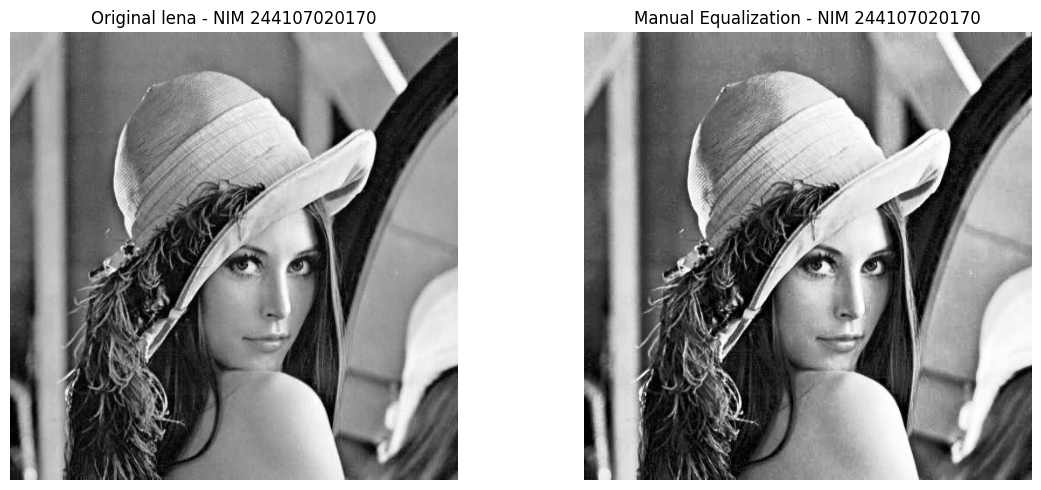

In [21]:
lena_lc = cv.imread(
    CONTOH + '/lena.jpg',
    cv.IMREAD_GRAYSCALE
)

assert lena_lc is not None, "lena.jpg tidak ditemukan!"

lena_eq_manual = manual_equalize(lena_lc)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(lena_lc, cmap='gray')
axes[0].set_title(f'Original lena - NIM {NIM}')
axes[0].axis('off')

axes[1].imshow(lena_eq_manual, cmap='gray')
axes[1].set_title(f'Manual Equalization - NIM {NIM}')
axes[1].axis('off')

plt.tight_layout()
plt.show()

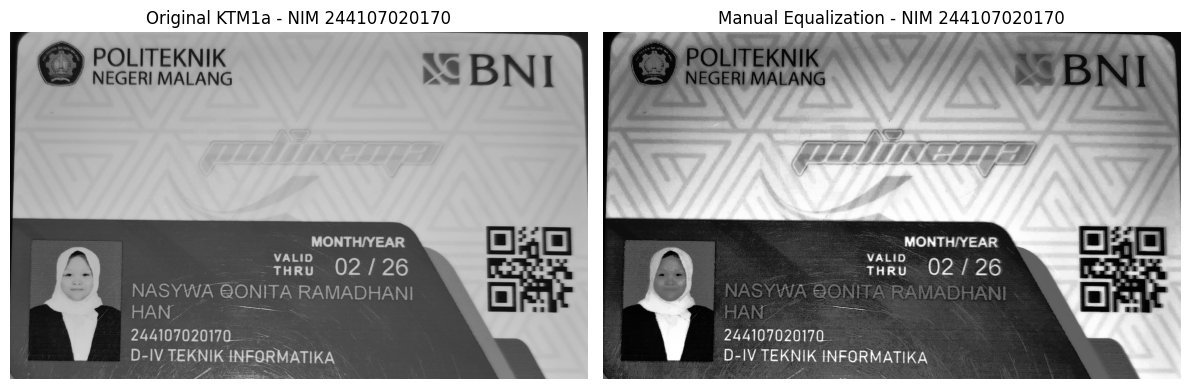

In [22]:
ktm1a = cv.imread(
    BASE + '/KTM1a.jpeg',
    cv.IMREAD_GRAYSCALE
)

assert ktm1a is not None, "KTM1a.jpeg tidak ditemukan!"

ktm1a_eq_manual = manual_equalize(ktm1a)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(ktm1a, cmap='gray')
axes[0].set_title(f'Original KTM1a - NIM {NIM}')
axes[0].axis('off')

axes[1].imshow(ktm1a_eq_manual, cmap='gray')
axes[1].set_title(f'Manual Equalization - NIM {NIM}')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [23]:
lena_eq_cv = cv.equalizeHist(lena_lc)
ktm1a_eq_cv = cv.equalizeHist(ktm1a)

diff_lena = np.max(
    np.abs(
        lena_eq_manual.astype(np.int16) -
        lena_eq_cv.astype(np.int16)
    )
)

diff_ktm1a = np.max(
    np.abs(
        ktm1a_eq_manual.astype(np.int16) -
        ktm1a_eq_cv.astype(np.int16)
    )
)

print("Max difference lena_lc :", diff_lena)
print("Max difference KTM1a   :", diff_ktm1a)

Max difference lena_lc : 0
Max difference KTM1a   : 0


The manual implementation and cv.equalizeHist() should produce the same or nearly the same result when the same histogram equalization formulation is used. If a small non-zero difference appears, it can be caused by differences in rounding or the implementation details of the lookup-table calculation.

In [24]:
def equalize_bgr_channels(img):
    channels = cv.split(img)

    eq_channels = [
        cv.equalizeHist(ch)
        for ch in channels
    ]

    return cv.merge(eq_channels)


def equalize_ycrcb(img):
    ycrcb = cv.cvtColor(img, cv.COLOR_BGR2YCrCb)

    ycrcb[:, :, 0] = cv.equalizeHist(ycrcb[:, :, 0])

    return cv.cvtColor(
        ycrcb,
        cv.COLOR_YCrCb2BGR
    )


def equalize_hsv(img):
    hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)

    hsv[:, :, 2] = cv.equalizeHist(hsv[:, :, 2])

    return cv.cvtColor(
        hsv,
        cv.COLOR_HSV2BGR
    )


def equalize_lab(img):
    lab = cv.cvtColor(img, cv.COLOR_BGR2LAB)

    lab[:, :, 0] = cv.equalizeHist(lab[:, :, 0])

    return cv.cvtColor(
        lab,
        cv.COLOR_LAB2BGR
    )

In [26]:
ktm1a_color = cv.imread(BASE + '/KTM1a.jpeg')

assert ktm1a_color is not None, "KTM1a.jpeg tidak ditemukan!"

eq_bgr = equalize_bgr_channels(ktm1a_color)
eq_ycrcb = equalize_ycrcb(ktm1a_color)
eq_hsv = equalize_hsv(ktm1a_color)
eq_lab = equalize_lab(ktm1a_color)

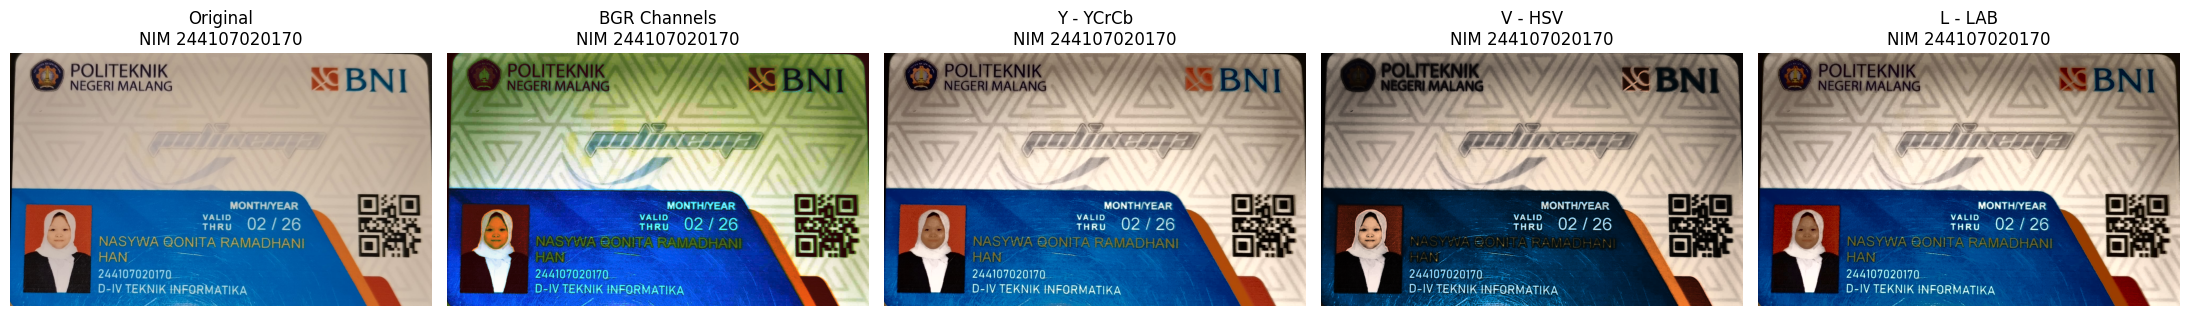

In [27]:
images = [
    ('Original', ktm1a_color),
    ('BGR Channels', eq_bgr),
    ('Y - YCrCb', eq_ycrcb),
    ('V - HSV', eq_hsv),
    ('L - LAB', eq_lab)
]

fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for ax, (title, img) in zip(axes, images):

    ax.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    ax.set_title(f'{title}\nNIM {NIM}')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [28]:
def hue_shift(original, result):

    hsv_original = cv.cvtColor(
        original,
        cv.COLOR_BGR2HSV
    )

    hsv_result = cv.cvtColor(
        result,
        cv.COLOR_BGR2HSV
    )

    h1 = hsv_original[:, :, 0].astype(np.int16)
    h2 = hsv_result[:, :, 0].astype(np.int16)

    diff = np.abs(h1 - h2)

    circular_diff = np.minimum(
        diff,
        180 - diff
    )

    return np.mean(circular_diff)

In [29]:
methods = {
    'BGR Channels': eq_bgr,
    'Y - YCrCb': eq_ycrcb,
    'V - HSV': eq_hsv,
    'L - LAB': eq_lab
}

for name, result in methods.items():

    shift = hue_shift(
        ktm1a_color,
        result
    )

    print(f'{name:15s}: Hue shift = {shift:.4f}')

BGR Channels   : Hue shift = 19.5478
Y - YCrCb      : Hue shift = 1.0711
V - HSV        : Hue shift = 0.5465
L - LAB        : Hue shift = 1.8755


E-2 Question 1

Which method produces the largest Hue shift, and what is the value?


The method with the largest Hue shift is [METHOD], with a mean Hue shift of [VALUE] degrees.


E-2 Question 2

Why does brightness-channel equalization still produce nonzero Hue shift?


Although the equalization is applied only to the brightness-related channel, the image must be converted back to BGR. During this conversion, rounding and clipping can slightly change the resulting RGB values. When the RGB values are converted to HSV again, these small changes can produce a nonzero Hue shift.

E-2 Question 3


Among Y, V, and L, the most suitable method for my KTM image is [METHOD]. It provides a better balance between brightness improvement and color preservation. The most noticeable improvement occurs in the [REGION], where the text/details become more visible without producing excessive changes in the surrounding colors.

In [30]:
clahe = cv.createCLAHE(
    clipLimit=PARAM['clip'],
    tileGridSize=(
        PARAM['tile'],
        PARAM['tile']
    )
)

ktm1a_clahe = clahe.apply(ktm1a)

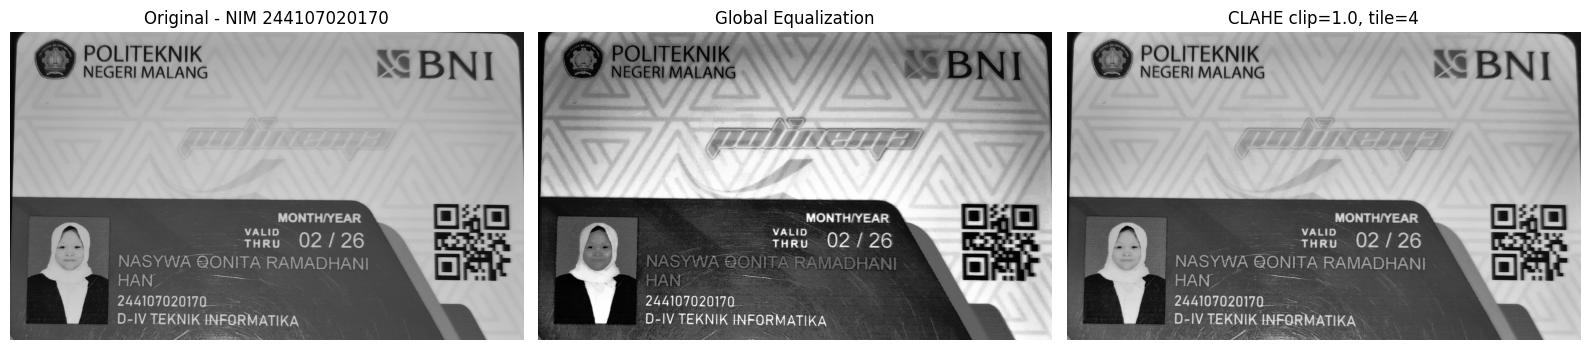

In [31]:
global_eq = cv.equalizeHist(ktm1a)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(ktm1a, cmap='gray')
axes[0].set_title(f'Original - NIM {NIM}')
axes[0].axis('off')

axes[1].imshow(global_eq, cmap='gray')
axes[1].set_title('Global Equalization')
axes[1].axis('off')

axes[2].imshow(ktm1a_clahe, cmap='gray')
axes[2].set_title(
    f'CLAHE clip={PARAM["clip"]}, tile={PARAM["tile"]}'
)
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [32]:
print("Original mean brightness :", np.mean(ktm1a))
print("Global mean brightness   :", np.mean(global_eq))
print("CLAHE mean brightness    :", np.mean(ktm1a_clahe))

Original mean brightness : 136.59803785119666
Global mean brightness   : 129.122008975026
CLAHE mean brightness    : 139.3826814516129


E-2 Practicum Question 1 — PSNR

In [33]:
def calculate_psnr(original, processed):

    mse = np.mean(
        (original.astype(np.float64) -
         processed.astype(np.float64)) ** 2
    )

    if mse == 0:
        return float('inf')

    return 10 * np.log10(
        (255 ** 2) / mse
    )


psnr_ktm1a = calculate_psnr(
    ktm1a,
    global_eq
)

print("PSNR KTM1a =", psnr_ktm1a, "dB")

PSNR KTM1a = 18.566357381730136 dB


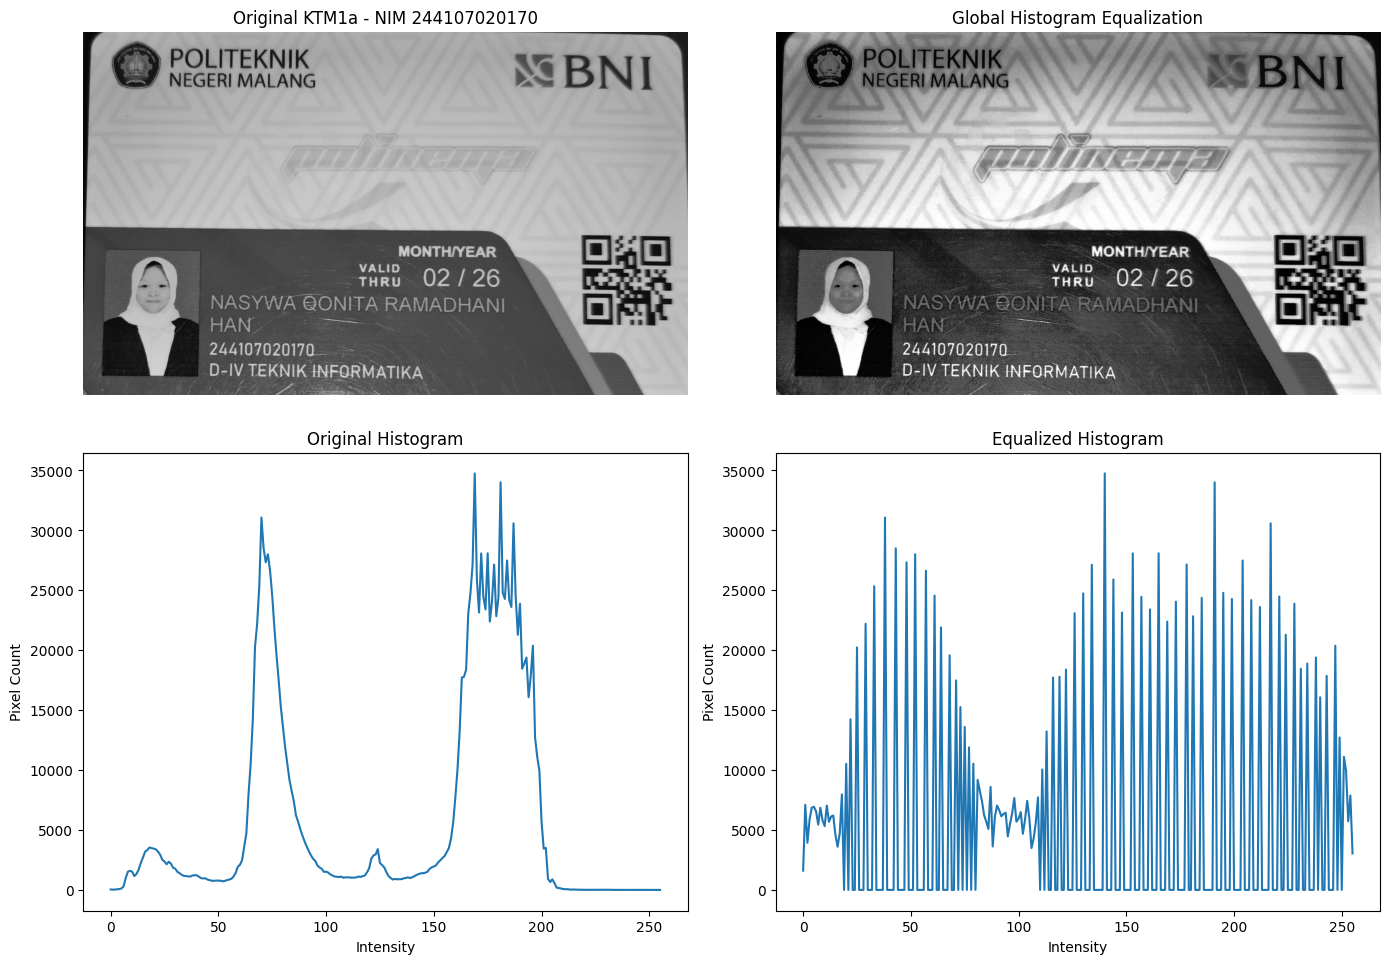

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].imshow(ktm1a, cmap='gray')
axes[0, 0].set_title(f'Original KTM1a - NIM {NIM}')
axes[0, 0].axis('off')

axes[0, 1].imshow(global_eq, cmap='gray')
axes[0, 1].set_title('Global Histogram Equalization')
axes[0, 1].axis('off')

axes[1, 0].plot(histogram_manual(ktm1a))
axes[1, 0].set_title('Original Histogram')
axes[1, 0].set_xlabel('Intensity')
axes[1, 0].set_ylabel('Pixel Count')

axes[1, 1].plot(histogram_manual(global_eq))
axes[1, 1].set_title('Equalized Histogram')
axes[1, 1].set_xlabel('Intensity')
axes[1, 1].set_ylabel('Pixel Count')

plt.tight_layout()
plt.show()

The PSNR decreases because histogram equalization intentionally changes the pixel intensities of the original image to improve contrast. Therefore, the equalized image becomes less similar to the original in terms of pixel-by-pixel numerical values. However, a lower PSNR does not necessarily mean that the text is less readable. PSNR measures numerical similarity rather than visual readability, so it is not sufficient as the only metric for evaluating KTM text readability.

E-2 Question 2 — CLAHE

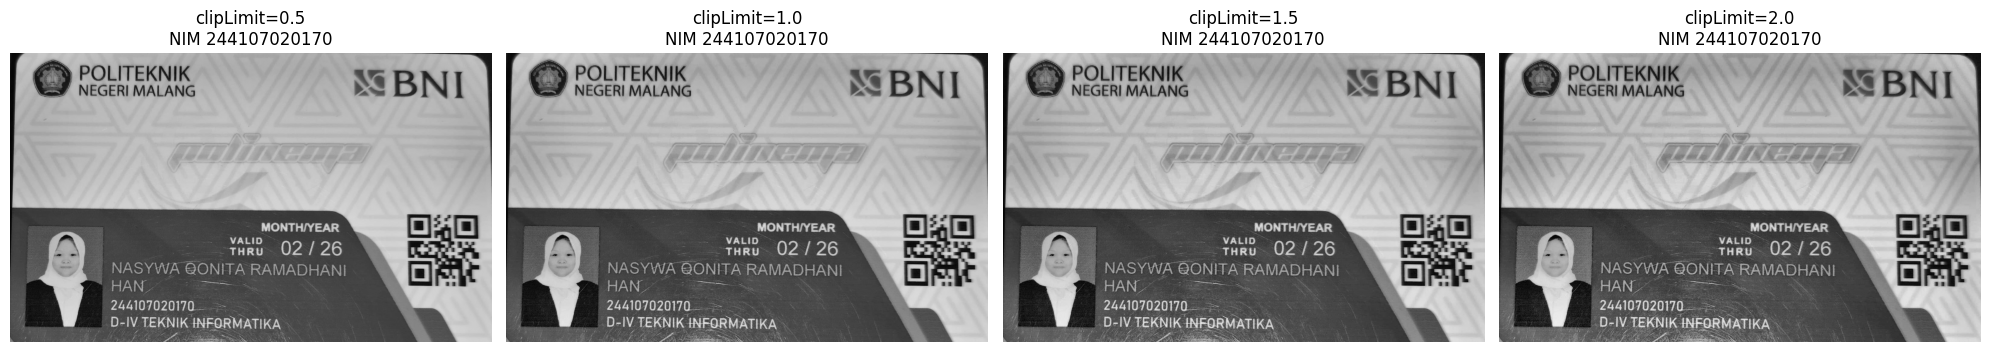

In [35]:
base_clip = PARAM['clip']

clip_values = [
    max(0.1, base_clip - 0.5),
    base_clip,
    base_clip + 0.5,
    base_clip + 1.0
]

fig, axes = plt.subplots(
    1,
    len(clip_values),
    figsize=(20, 5)
)

for ax, clip_value in zip(axes, clip_values):

    clahe_test = cv.createCLAHE(
        clipLimit=clip_value,
        tileGridSize=(
            PARAM['tile'],
            PARAM['tile']
        )
    )

    result = clahe_test.apply(ktm1a)

    ax.imshow(result, cmap='gray')
    ax.set_title(
        f'clipLimit={clip_value}\nNIM {NIM}'
    )
    ax.axis('off')

plt.tight_layout()
plt.show()

The CLAHE result with clipLimit = [VALUE] provides the most suitable balance for my KTM image. At a lower clipLimit, the contrast enhancement is more limited, while increasing the clipLimit makes local contrast stronger. At higher values, noise and unwanted background details become more visible, especially in the [REGION]. Therefore, the selected value provides sufficient enhancement while avoiding excessive noise amplification.

In [36]:
def floyd_steinberg(gray, L=2):

    img = gray.astype(np.float32).copy()

    step = 255.0 / (L - 1)

    H, W = img.shape

    for y in range(H):
        for x in range(W):

            old_value = img[y, x]

            new_value = (
                np.round(old_value / step) *
                step
            )

            img[y, x] = new_value

            error = old_value - new_value

            if x + 1 < W:
                img[y, x + 1] += error * 7 / 16

            if x > 0 and y + 1 < H:
                img[y + 1, x - 1] += error * 3 / 16

            if y + 1 < H:
                img[y + 1, x] += error * 5 / 16

            if x + 1 < W and y + 1 < H:
                img[y + 1, x + 1] += error * 1 / 16

    return np.clip(
        img,
        0,
        255
    ).astype(np.uint8)

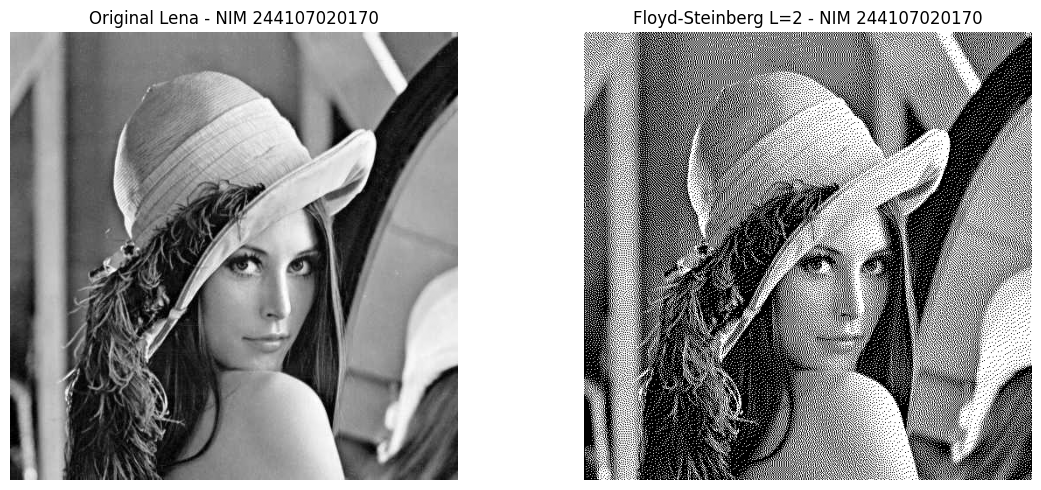

In [37]:
lena = cv.imread(
    CONTOH + '/lena.jpg',
    cv.IMREAD_GRAYSCALE
)

assert lena is not None, "lena.jpg tidak ditemukan!"

lena_dither = floyd_steinberg(
    lena,
    L=2
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(lena, cmap='gray')
axes[0].set_title(f'Original Lena - NIM {NIM}')
axes[0].axis('off')

axes[1].imshow(lena_dither, cmap='gray')
axes[1].set_title(f'Floyd-Steinberg L=2 - NIM {NIM}')
axes[1].axis('off')

plt.tight_layout()
plt.show()

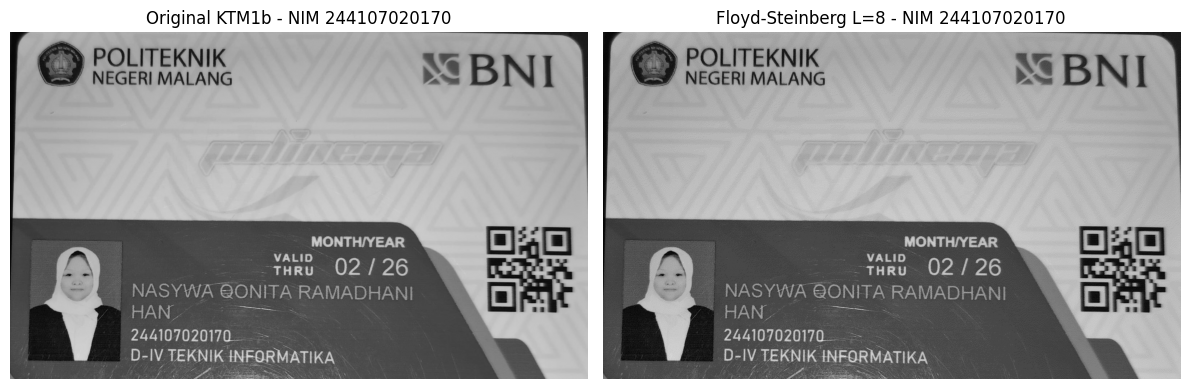

In [38]:
ktm1b_dither = floyd_steinberg(
    img_ktm,
    L=PARAM['L']
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img_ktm, cmap='gray')
axes[0].set_title(f'Original KTM1b - NIM {NIM}')
axes[0].axis('off')

axes[1].imshow(ktm1b_dither, cmap='gray')
axes[1].set_title(
    f'Floyd-Steinberg L={PARAM["L"]} - NIM {NIM}'
)
axes[1].axis('off')

plt.tight_layout()
plt.show()

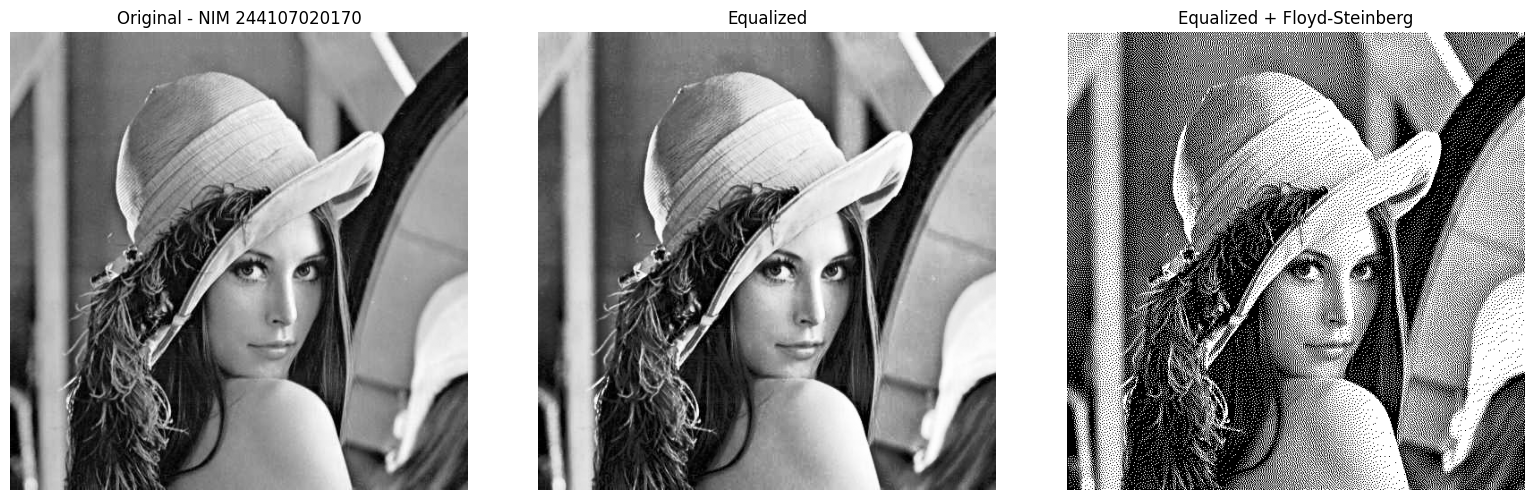

In [41]:
lena_lc_gray = cv.imread(
    CONTOH + '/lena.jpg',
    cv.IMREAD_GRAYSCALE
)

lena_lc_eq = cv.equalizeHist(lena_lc_gray)

lena_lc_eq_dither = floyd_steinberg(
    lena_lc_eq,
    L=2
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(lena_lc_gray, cmap='gray')
axes[0].set_title(f'Original - NIM {NIM}')
axes[0].axis('off')

axes[1].imshow(lena_lc_eq, cmap='gray')
axes[1].set_title('Equalized')
axes[1].axis('off')

axes[2].imshow(lena_lc_eq_dither, cmap='gray')
axes[2].set_title('Equalized + Floyd-Steinberg')
axes[2].axis('off')

plt.tight_layout()
plt.show()

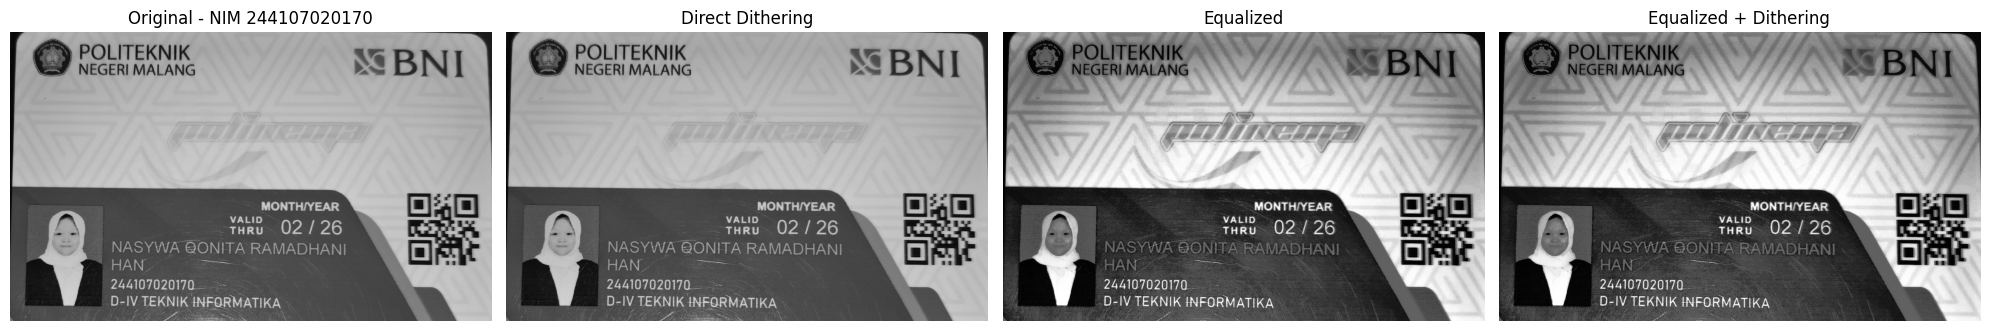

In [42]:
ktm1a_eq = cv.equalizeHist(ktm1a)

ktm1a_eq_dither = floyd_steinberg(
    ktm1a_eq,
    L=PARAM['L']
)

ktm1a_direct_dither = floyd_steinberg(
    ktm1a,
    L=PARAM['L']
)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(ktm1a, cmap='gray')
axes[0].set_title(f'Original - NIM {NIM}')
axes[0].axis('off')

axes[1].imshow(ktm1a_direct_dither, cmap='gray')
axes[1].set_title('Direct Dithering')
axes[1].axis('off')

axes[2].imshow(ktm1a_eq, cmap='gray')
axes[2].set_title('Equalized')
axes[2].axis('off')

axes[3].imshow(ktm1a_eq_dither, cmap='gray')
axes[3].set_title('Equalized + Dithering')
axes[3].axis('off')

plt.tight_layout()
plt.show()

The equalization-then-dithering process changes the intensity distribution before reducing the image to the selected number of levels. Compared with direct dithering, the equalized image can provide stronger contrast in regions where the original image has limited intensity variation. Therefore, the method that produces clearer KTM text in my result is [METHOD], particularly in the [REGION].

In [43]:
test = np.array([
    [100, 150, 200],
    [50,  125, 225],
    [80,  180, 240]
], dtype=np.uint8)

print(test)

[[100 150 200]
 [ 50 125 225]
 [ 80 180 240]]


For the first pixel with an intensity of 100 and L = 2, the quantization step is 255. The new value is 0, so the quantization error is 100. The error is distributed to the neighboring pixels using 7/16, 3/16, 5/16, and 1/16. The distributed errors are 43.75, 18.75, 31.25, and 6.25 respectively. Their sum is 100, confirming that the complete quantization error is distributed according to the Floyd-Steinberg kernel.